# **Project Pipeline Overview – Conditional Variational Autoencoder (CVAE)**

In this notebook , I implemented a **Conditional Variational Autoencoder (CVAE)** using **PyTorch** to learn a structured latent representation of human faces from the CelebA dataset, enabling controlled manipulation of facial attributes, specifically the “Smiling” attribute.

#**The full pipeline of the project**


##**1. Environment Setup**

\- Install and import all required libraries (PyTorch, Torchvision, Matplotlib).

\- Detect and configure GPU/CPU execution.

In [48]:
!pip install torch torchvision matplotlib


###**Import Dependencies & Device Configuration**

In [49]:
# Core libraries
import torch
import torchvision # for datasets and image transformations
from torch import nn, optim # neural network modules (leyrs and loss function)
from torch.utils.data import DataLoader, random_split , Dataset
from torchvision import transforms, datasets # image transformations and datasets from torchvision
import matplotlib.pyplot as plt
import numpy as np # for numerical operations
import pandas as pd
import os
from PIL import Image



###**checks whether a GPU is available and selects the appropriate device**

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#**Dataset processing**

All face images are first resized to **64×64** pixels to ensure a fixed input size, which is required for convolutional networks.

\- The images are then converted into **PyTorch tensors**, transforming pixel values from integers into floating-point numbers.

\- Next, pixel values are **normalized from [0,1] to [-1,1]**. This step stabilizes training and matches the decoder’s final activation function **(tanh)**, which also outputs values in the range [-1,1].

\- the **“Smiling”&& attribute is extracted from the dataset annotations and converted into a binary condition:
: 0 → Not smiling , 1 → Smiling

\- To **speed up training** and experimentation, only 2,500 images are used. These images are split into training (80%) and validation (20%) sets.

\- DataLoaders are then created to feed batches of images and labels to the model efficiently.

In [51]:

transform = transforms.Compose([

    # resize inputs to 64*64 : all images have the same size
    transforms.Resize((64, 64)),

    # conversion into pytorch tensor and scales pixel value from [0,255] to [0 , 1]
    transforms.ToTensor(),

    #normalize each color = ( (pixel - 0.5 )/ 0.5 ) so from [0,1] to [-1 , 1] to train better
    transforms.Normalize([0.5]*3, [0.5]*3)
])

###**Load and Preprocess the CelebA Dataset**



This cell loads the **CelebA** dataset and applies image transformations.



In [52]:
import kagglehub

path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(path)

dataset = CelebADataset(
    img_dir=f"{path}/img_align_celeba/img_align_celeba",
    attr_file=f"{path}/list_attr_celeba.csv",
    transform=transform
)


Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


 The dataset size is reduced to speed up training.

In [57]:
from torch.utils.data import Subset, DataLoader

small_total = 2500  # total images to use

# Pick the first 2500 items using Subset
dataset_small = Subset(dataset, list(range(small_total)))

# Split 80/20 for train/val
train_size = int(0.8 * small_total)  # 2000
val_size = small_total - train_size  # 500
train_ds, val_ds = torch.utils.data.random_split(dataset_small, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=0)


##**some example visualisation**

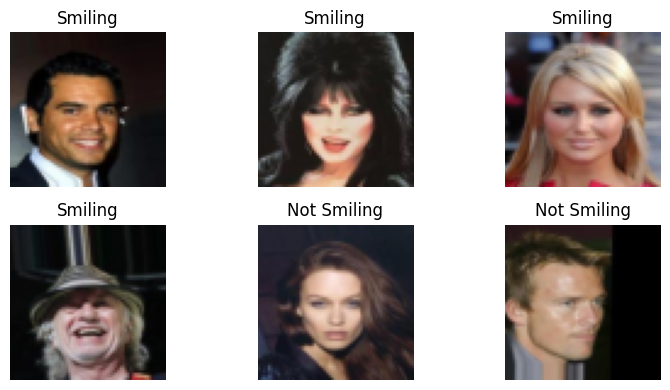

In [58]:
import matplotlib.pyplot as plt

# Function to show a few images from a DataLoader
def show_samples(loader, n=6):
    plt.figure(figsize=(8,4))
    count = 0

    for imgs, labels in loader:
        for i in range(len(imgs)):
            # Unnormalize image from [-1,1] to [0,1]
            img = imgs[i] * 0.5 + 0.5

            # Make sure label is an integer
            label = int(labels[i])

            plt.subplot(2, 3, count + 1)
            plt.imshow(img.permute(1,2,0))
            plt.title("Smiling" if label==1 else "Not Smiling")
            plt.axis("off")

            count += 1
            if count >= n:
                break
        if count >= n:
            break

    plt.tight_layout()
    plt.show()

# Show first 6 images from the reduced training set
show_samples(train_loader, n=6)


###**Label distribution (class balance)**

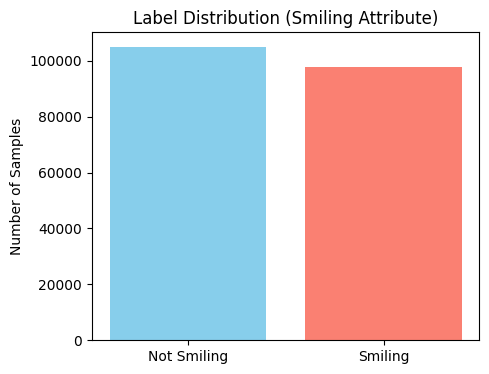

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Load attributes CSV directly
attr_file = f"{path}/list_attr_celeba.csv"
df = pd.read_csv(attr_file)

# Smiling column: +1 -> Smiling, -1 -> Not Smiling
labels = df['Smiling'].replace(-1, 0)  # Convert -1 to 0

# Count occurrences
counts = labels.value_counts().sort_index()  # 0 first, then 1

# Plot
plt.figure(figsize=(5,4))
plt.bar(["Not Smiling", "Smiling"], counts.values, color=['skyblue', 'salmon'])
plt.title("Label Distribution (Smiling Attribute)")
plt.ylabel("Number of Samples")
plt.show()



##**3. Model Architecture**



The model is a **Conditional Variational Autoencoder (CVAE)**.
Its goal is not only to reconstruct images, but also to separate identity-related information **(face structure)** from **attribute-related information (smiling)**.

Two key dimensions are defined:

\- Latent dimension (latent_dim = 128) : the size of the compressed representation of each image. It is large enough to capture facial structure, but small enough to enforce meaningful compression.

\- Condition dimension (cond_dim = 1)
This represents the binary smiling attribute (0 or 1).

###**Model configuration**

128 is standard latent size for celebA at 64*64 resolution
- large enough to encode facial structure
- small enough to keep KL loss stable

cond_dim = 1  because the binary conditioning (0/1)

In [60]:
latent_dim = 128 # Dimension of the latent space vector

cond_dim = 1  # Number of conditional classes (smiling / not smiling)


###**The encoder network : Compressing the Image into a Latent Representation**


The encoder receives two inputs:

\- The face image   \- The condition label (smiling / not smiling)

The **condition label** is spatially broadcast and concatenated to the image as an **additional channel**, allowing the encoder to learn features conditioned on the attribute.

The encoder consists of three convolutional layers that progressively reduce spatial resolution:

\- 64×64 → 32×32  \- 32×32 → 16×16  \- 16×16 → 8×8

While spatial size decreases, the number of feature channels increases, allowing the network to extract higher-level facial features.
After the **final convolution**, the feature map has shape **(128, 8, 8)**.

This tensor is then **flattened** into a **1D vector** of size **128 × 8 × 8**.
This vector is a **compressed summary** of the image, but it is not yet the **latent space**.

compresses the input image + condition into a compact vector that represents the image in the latent space, ready for the VAE’s μ and logσ² layers.

In [61]:
encoder = nn.Sequential(

    nn.Conv2d(3 + 1, 32, 4, 2, 1),
    # 3RGB + 1 conditional label
    # outputs 32 feature maps
    #kernel size 4 and stride =  2 : reduces spatial dimension by half
    # padding =1
    # output =  [(in +2*padding - kernel size )/ stride ] +1 =32
    nn.ReLU(), # for adding non-linearity

    nn.Conv2d(32, 64, 4, 2, 1),
    nn.ReLU(),
    # result ()
    nn.Conv2d(64, 128, 4, 2, 1),
    nn.ReLU(), #ouput = 8
    # channel = 128
    # flatten _> 128*8*8

    nn.Flatten() # Flatten feature maps into a vector 1D to feed fully-connected layers for u and logo^2 (latent space)

).to(device)


###**Latent Space and Probabilistic Representation**



Instead of mapping each image to a single fixed point, a **Variational Autoencoder** models each **image** as a **probability distribution** in **latent space**.

From the encoder’s flattened output, two separate linear layers predict:

\- μ (mean vector)  \- log σ² (log-variance vector)

Both vectors have size 128, matching the latent dimension.

Together, they define a **Gaussian distribution** for each image in latent space.

     - Each image corresponds to a region, not a single point

    - Nearby points represent visually similar faces

    - The latent space becomes smooth and structured

In [ ]:
# Fully connected layer to predict latent mean μ
fc_mu = nn.Linear(128 * 8 * 8, latent_dim).to(device)

# Fully connected layer to predict latent log-variance log(σ²)
fc_logvar = nn.Linear(128 * 8 * 8, latent_dim).to(device)

###**The decoder network**


The decoder performs the inverse operation of the encoder.

Its input is:

\- The latent vector z

\- The target condition (smiling or not smiling)

These two are concatenated, forming a vector that contains:

\- Who the person is (latent identity)

\- How the person should look (attribute)

A linear layer maps this combined vector back to a size of 128 × 8 × 8.
This vector is reshaped into feature maps and passed through transposed convolution layers, which progressively upsample:

\- 8×8 → 16×16   \- 16×16 → 32×32   \- 32×32 → 64×64

The final output is a **reconstructed RGB image**.

A **tanh activation** ensures that the output values match the normalized input range.

In [62]:
# Linear layer to map latent vector + condition to decoder input to 128*8*8
decoder_input = nn.Linear(latent_dim + cond_dim, 128 * 8 * 8).to(device)

decoder = nn.Sequential(
    # Reshape vector back to feature maps
    nn.Unflatten(1, (128, 8, 8)),

    # First transposed convolution (upsampling)
    nn.ConvTranspose2d(128, 64, 4, 2, 1),
    nn.ReLU(),

    # Second transposed convolution
    nn.ConvTranspose2d(64, 32, 4, 2, 1),
    nn.ReLU(),

    # Final transposed convolution to reconstruct RGB image
    nn.ConvTranspose2d(32, 3, 4, 2, 1),

    nn.Tanh() # output in [-1,1] to match normalized images input

).to(device)


##**Reparameterization Trick : Sampling the Latent vector**


To generate a **latent vector** while still allowing **backpropagation**, the reparameterization trick is used.

Instead of sampling directly from the Gaussian distribution, the model:

\- Samples random noise ε from a standard normal distribution

\- Scales it by the learned variance

\- Shifts it by the learned mean

This produces a **latent vector z**, which:

    - Encodes the identity of the face

    - Includes controlled randomness

    - Can be optimized using gradient descent

In [63]:
def reparameterize(mu, logvar):

    # Compute standard deviation from log-variance
    std = torch.exp(0.5 * logvar)

    # Sample random noise ε from standard normal distribution
    eps = torch.randn_like(std)

    # Generate latent vector z
    return mu + eps * std


###**LOSS Function and Latent Refularization**

Training is guided by two complementary objectives:

1. Reconstruction loss (MSE) : Ensures the output image is visually similar to the input.

2. KL divergence loss : Forces the learned latent distributions to stay close to a standard normal distribution.

This balance ensures that:

    - The model reconstructs images accurately

    - The latent space remains smooth, continuous, and well-structured

A **weighting factor (β)** controls how strongly the latent space is regularized.

In [64]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = nn.MSELoss(reduction="sum")(recon_x, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl



##**Training Phase**


During training:

1. Images and labels are passed through the encoder

2. Latent distributions are computed

3. Latent vectors are sampled

4. Images are reconstructed by the decoder

5. Loss is computed and backpropagated

The **encoder** and **decoder** are **optimized jointly** using the **Adam optimizer**.

Validation is periodically performed to monitor generalization.

####**Optimizer and Training Configuration**


In [65]:
lr = 1e-3
epochs = 30
beta = 0.1   # KL weight (important)

params = (
    list(encoder.parameters()) +
    list(fc_mu.parameters()) +
    list(fc_logvar.parameters()) +
    list(decoder_input.parameters()) +
    list(decoder.parameters())
)

optimizer = optim.Adam(params, lr=lr)


####**Forward Pass**

In [66]:
def forward_cvae(x, y):
# x : images
# y : conditioning labels (smiling / not smiling)

    y = y.to(x.device)
    # ----- Encoder conditioning -----
    y_img = y.view(-1,1,1,1).repeat(1,1,64,64)
    x_cond = torch.cat([x, y_img], dim=1)

    h = encoder(x_cond)
    mu = fc_mu(h)
    logvar = fc_logvar(h)

    z = reparameterize(mu, logvar)

    # ----- Decoder conditioning -----
    y = y.float().unsqueeze(1)  # (B,1)
    z_cond = torch.cat([z, y], dim=1)

    dec_input = decoder_input(z_cond)
    recon_x = decoder(dec_input)

    return recon_x, mu, logvar


####**Training the CVAE Model : The model training Loop**

In [67]:
from torch.cuda.amp import autocast, GradScaler

# Mixed precision scaler
scaler = GradScaler()

# Optimized DataLoaders
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, pin_memory=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, pin_memory=True, num_workers=4)

train_losses = []
val_losses = []
recon_losses = []
kl_losses = []

for epoch in range(epochs):
    # ======================
    # Training
    # ======================
    encoder.train()
    decoder.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, y in train_loader:
        # Move tensors to GPU and ensure float
        x = x.to(device)
        y = y.float().to(device)

        optimizer.zero_grad()

        # Mixed precision forward
        with autocast():
            recon_x, mu, logvar = forward_cvae(x, y)

            recon_loss = nn.MSELoss(reduction="sum")(recon_x, x)
            kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + beta * kl

        # Backprop with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl.item()

    train_losses.append(total_loss / len(train_loader.dataset))
    recon_losses.append(total_recon / len(train_loader.dataset))
    kl_losses.append(total_kl / len(train_loader.dataset))

    # ======================
    # Validation every 2 epochs
    # ======================
    if (epoch + 1) % 2 == 0 or epoch == epochs - 1:
        encoder.eval()
        decoder.eval()

        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.float().to(device)

                recon_x, mu, logvar = forward_cvae(x, y)

                recon_loss = nn.MSELoss(reduction="sum")(recon_x, x)
                kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
                loss = recon_loss + beta * kl
                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader.dataset))

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_losses[-1]:.4f} | "
            f"Val Loss: {val_losses[-1]:.4f} | "
            f"Recon: {recon_losses[-1]:.4f} | KL: {kl_losses[-1]:.4f}"
        )
    else:
        # If not validating, still print training loss
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_losses[-1]:.4f} | "
            f"Recon: {recon_losses[-1]:.4f} | KL: {kl_losses[-1]:.4f}"
        )


/tmp/ipython-input-4205499674.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-4205499674.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/30] | Train Loss: 4664.4536 | Recon: 4657.9179 | KL: 65.3567
Epoch [2/30] | Train Loss: 4526.5500 | Val Loss: 3598.3592 | Recon: 4447.9012 | KL: 786.4883
Epoch [3/30] | Train Loss: 3277.6466 | Recon: 3262.6083 | KL: 150.3824
Epoch [4/30] | Train Loss: 2580.1255 | Val Loss: 2066.5717 | Recon: 2559.2501 | KL: 208.7535
Epoch [5/30] | Train Loss: 1720.0075 | Recon: 1690.3947 | KL: 296.1279
Epoch [6/30] | Train Loss: 1216.3862 | Val Loss: 1106.4799 | Recon: 1188.8253 | KL: 275.6094
Epoch [7/30] | Train Loss: 1037.6556 | Recon: 1008.0354 | KL: 296.2018
Epoch [8/30] | Train Loss: 908.6675 | Val Loss: 882.7912 | Recon: 878.1339 | KL: 305.3357
Epoch [9/30] | Train Loss: 813.0497 | Recon: 781.2008 | KL: 318.4893
Epoch [10/30] | Train Loss: 752.4986 | Val Loss: 762.8335 | Recon: 720.4155 | KL: 320.8313
Epoch [11/30] | Train Loss: 703.5106 | Recon: 670.8871 | KL: 326.2352
Epoch [12/30] | Train Loss: 654.1113 | Val Loss: 670.2099 | Recon: 621.1416 | KL: 329.6979
Epoch [13/30] | Train Loss:

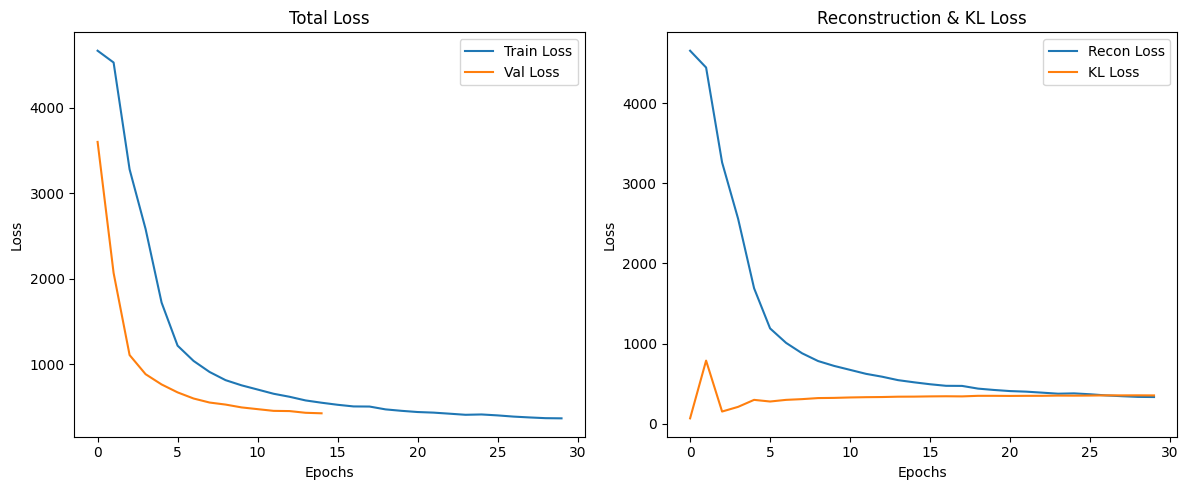

In [72]:
def plot_training_curves(train_losses, val_losses, recon_losses, kl_losses):
    plt.figure(figsize=(12,5))

    # Total loss
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Total Loss')
    plt.legend()

    # Recon & KL loss
    plt.subplot(1,2,2)
    plt.plot(recon_losses, label='Recon Loss')
    plt.plot(kl_losses, label='KL Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Reconstruction & KL Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function
plot_training_curves(train_losses, val_losses, recon_losses, kl_losses)


####**Interpretation**

\- Both training loss and validation loss decrease smoothly over epochs.

\- The validation loss closely follows the training loss.

\- There is no divergence between train and validation curves.

    This behavior indicates that the model is learning meaningful representations rather than memorizing the data and The training process is stable, and the model generalizes well to unseen validation images.

\- The reconstruction loss starts very high and decreases rapidly.

\- The KL divergence increases slightly at the beginning, then stabilizes at a low value.

\- Over time, both losses converge smoothly.

**At the start of training:**

\- The model focuses mainly on learning how to reconstruct faces.

\- The latent space is initially unstructured, so the KL term is unstable.

**As training progresses:**

\- The reconstruction becomes accurate.

\- The KL loss enforces a regularized, smooth latent space without overpowering reconstruction.

This balance is controlled by the β parameter.

    The model achieves a good trade-off between image quality and latent space regularization — exactly what a VAE should do.

###**Latent Space Visualization**

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


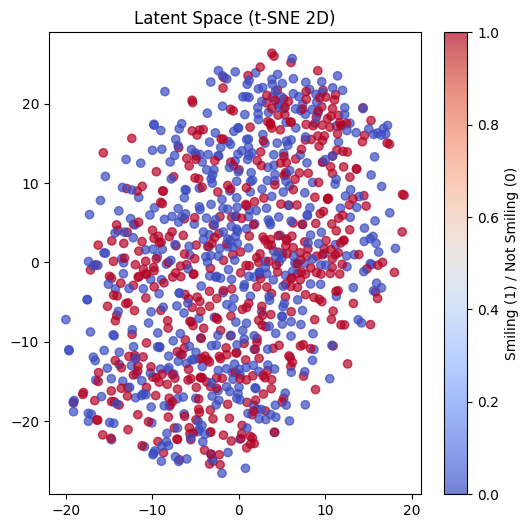

In [71]:
from sklearn.manifold import TSNE

def visualize_latent_space(loader, num_samples=1000):
    encoder.eval()
    all_z = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().unsqueeze(1)

            # Encoder conditioning
            y_img = y.view(-1,1,1,1).repeat(1,1,64,64)
            x_cond = torch.cat([x, y_img], dim=1)

            h = encoder(x_cond)
            mu = fc_mu(h)  # Use mean of latent as representation
            all_z.append(mu.cpu())
            all_labels.append(y.cpu())

            if len(all_z)*x.size(0) >= num_samples:
                break

    zs = torch.cat(all_z, dim=0)[:num_samples]
    labels = torch.cat(all_labels, dim=0)[:num_samples]

    # t-SNE to 2D
    tsne = TSNE(n_components=2, random_state=42)
    z_2d = tsne.fit_transform(zs)

    plt.figure(figsize=(6,6))
    plt.scatter(z_2d[:,0], z_2d[:,1], c=labels.squeeze(), cmap='coolwarm', alpha=0.7)
    plt.colorbar(label='Smiling (1) / Not Smiling (0)')
    plt.title("Latent Space (t-SNE 2D)")
    plt.show()

# Visualize 1000 samples from train_loader
visualize_latent_space(train_loader, num_samples=1000)


Smiling and non-smiling faces are not perfectly separated , which is expected and desirable.

\- Faces can be “slightly smiling”

\- Expressions exist on a continuum

###**Inference & Attribute Manipulation**




In the final stage, the model is used for controlled image generation:

\- Non-smiling faces are selected

\- Their latent identity is preserved

\- The condition is changed to “smiling”

\- The decoder generates a new image with the modified attribute

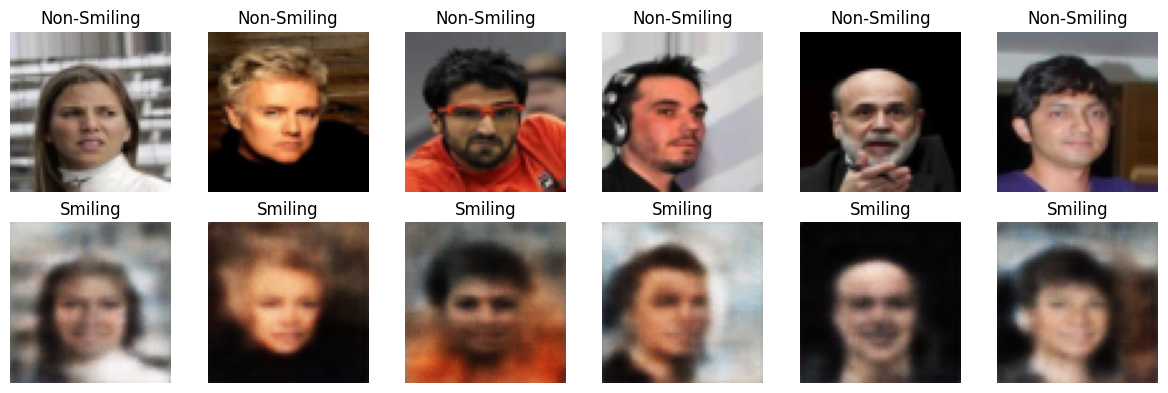

In [78]:
def generate_smiles(loader, num_images=6):
    encoder.eval()
    decoder.eval()

    plt.figure(figsize=(12, 4))
    count = 0

    with torch.no_grad():
        for x, y in loader:
            # Only take non-smiling images
            mask = (y == 0)
            if mask.sum() == 0:
                continue

            x_non_smile = x[mask].to(device)
            y_smile = torch.ones((x_non_smile.size(0),), dtype=torch.float32).to(device)  # shape (B,)

            # Forward pass through CVAE
            recon_smile, _, _ = forward_cvae(x_non_smile, y_smile)

            for i in range(len(x_non_smile)):
                # Original non-smiling
                orig = x_non_smile[i] * 0.5 + 0.5
                plt.subplot(2, num_images, count+1)
                plt.imshow(orig.permute(1,2,0).cpu())
                plt.title("Non-Smiling")
                plt.axis("off")

                # Generated smiling
                smile = recon_smile[i] * 0.5 + 0.5
                plt.subplot(2, num_images, count+1+num_images)
                plt.imshow(smile.permute(1,2,0).cpu())
                plt.title("Smiling")
                plt.axis("off")

                count += 1
                if count >= num_images:
                    break
            if count >= num_images:
                break

    plt.tight_layout()
    plt.show()

# Test on validation set
generate_smiles(val_loader, num_images=6)
